In [1]:
#Spotify Music Clustering (Clustering)

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')

df = pd.read_csv('SpotifyFeatures.csv')

df.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')

print(df.head())

   genre        artist_name                        track_name  \
0  Movie     Henri Salvador       C'est beau de faire un Show   
1  Movie  Martin & les fées  Perdu d'avance (par Gad Elmaleh)   
2  Movie    Joseph Williams    Don't Let Me Be Lonely Tonight   
3  Movie     Henri Salvador    Dis-moi Monsieur Gordon Cooper   
4  Movie       Fabien Nataf                         Ouverture   

                 track_id  popularity  acousticness  danceability  \
0  0BRjO6ga9RKCKjfDqeFgWV           0         0.611         0.389   
1  0BjC1NfoEOOusryehmNudP           1         0.246         0.590   
2  0CoSDzoNIKCRs124s9uTVy           3         0.952         0.663   
3  0Gc6TVm52BwZD07Ki6tIvf           0         0.703         0.240   
4  0IuslXpMROHdEPvSl1fTQK           4         0.950         0.331   

   duration_ms  energy  instrumentalness key  liveness  loudness   mode  \
0        99373   0.910             0.000  C#    0.3460    -1.828  Major   
1       137373   0.737             0.000  F#

In [7]:
df.isna().sum()  # No missing values
df.info()
df.shape  # (2017, 16)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

(232725, 18)

In [10]:
df.describe()


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


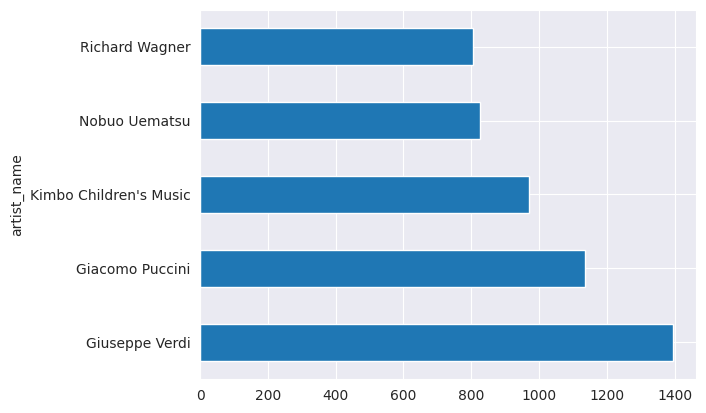

In [12]:
top_5_artists = df.groupby('artist_name')['track_name'].count().sort_values(ascending=False).head()
top_5_artists.plot(kind='barh')
plt.show()

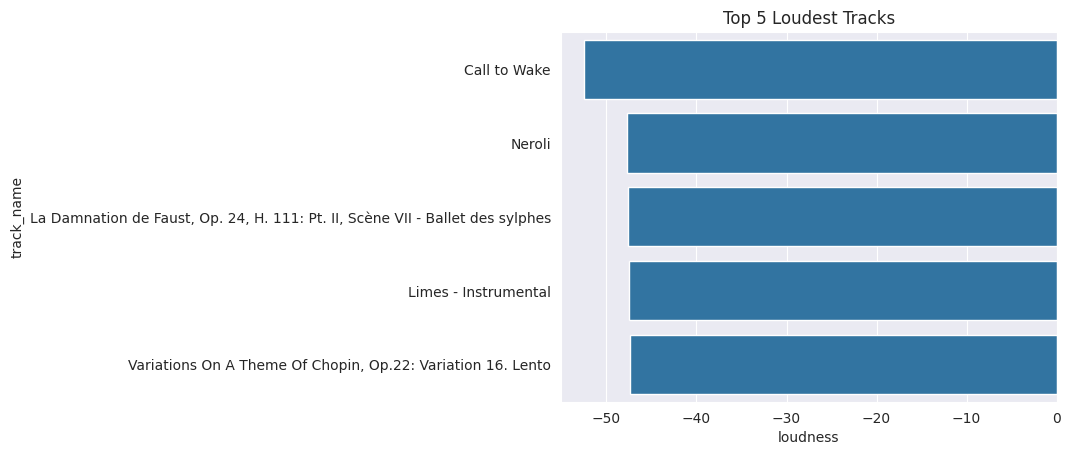

In [15]:
#Top 5 loudest tracks (loudness in dB, lower = louder):
top_5_loudest_tracks = df[['loudness', 'track_name']].sort_values('loudness').head()
sns.barplot(data=top_5_loudest_tracks, x='loudness', y='track_name')
plt.title('Top 5 Loudest Tracks')
plt.show()

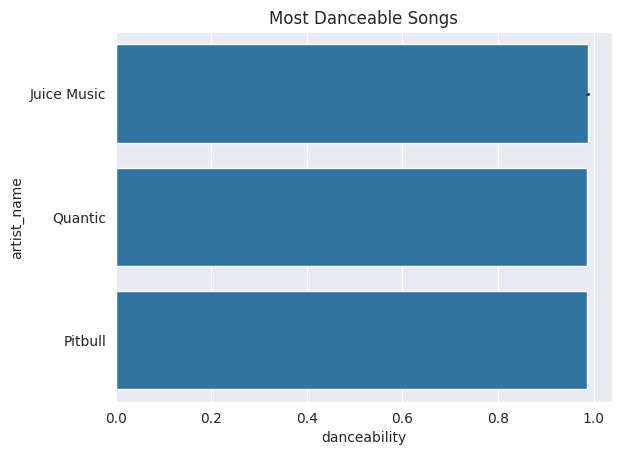

In [18]:
#Artist with most danceable songs:
top_danceable = df[['danceability', 'track_name', 'artist_name']].sort_values('danceability', ascending=False).head()
sns.barplot(data=top_danceable, x='danceability', y='artist_name')
plt.title('Most Danceable Songs')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

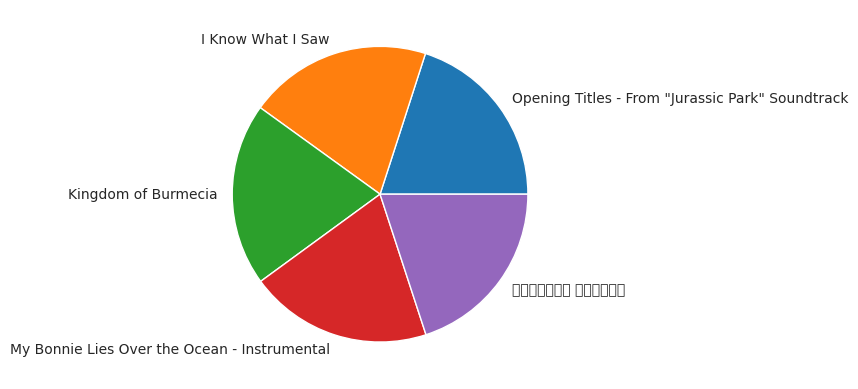

In [20]:
#Top instrumental tracks (instrumentalness >0.5 indicates no vocals):
top_instrumental = df[['instrumentalness', 'track_name', 'artist_name']].sort_values('instrumentalness', ascending=False).head()
plt.pie(top_instrumental['instrumentalness'], labels=top_instrumental['track_name'])
plt.show()

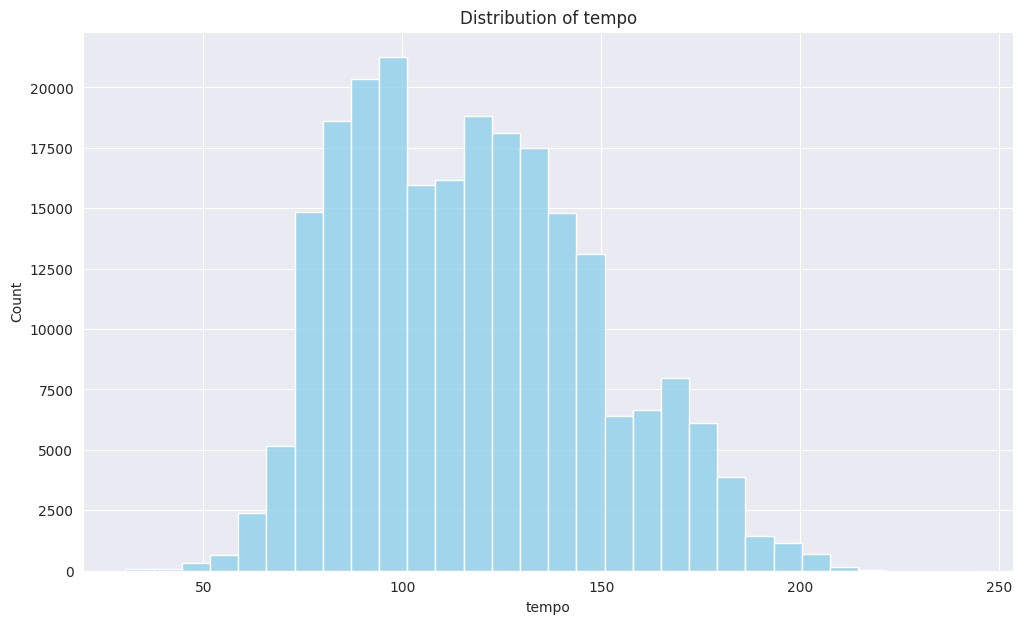

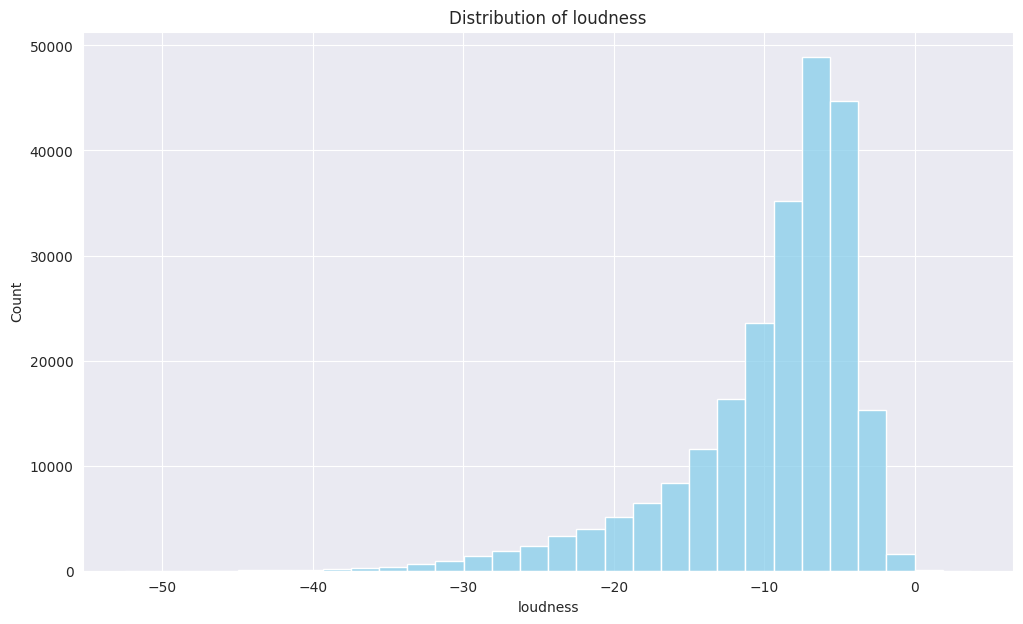

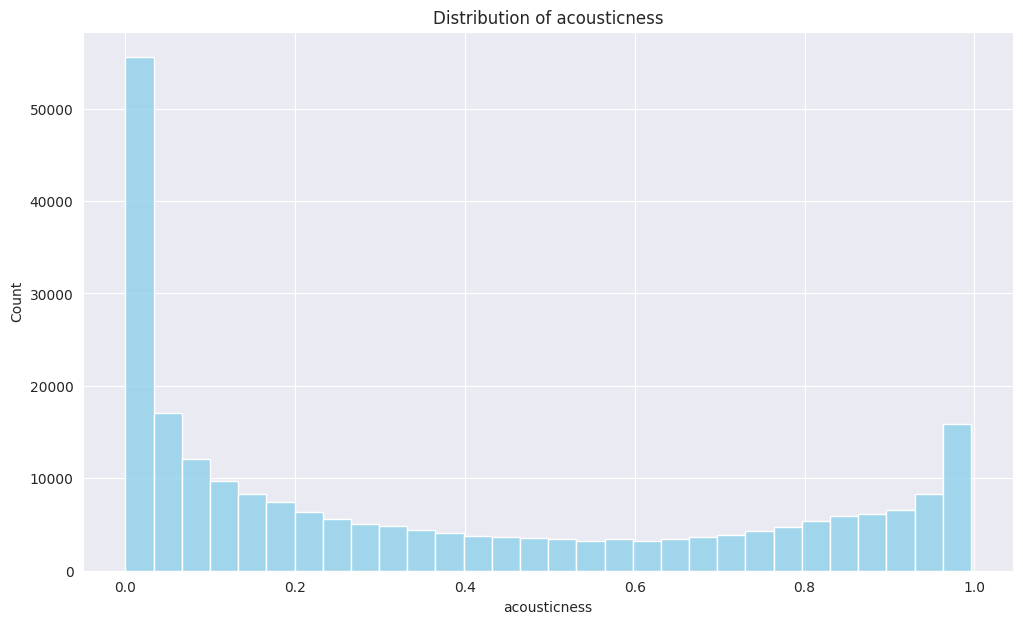

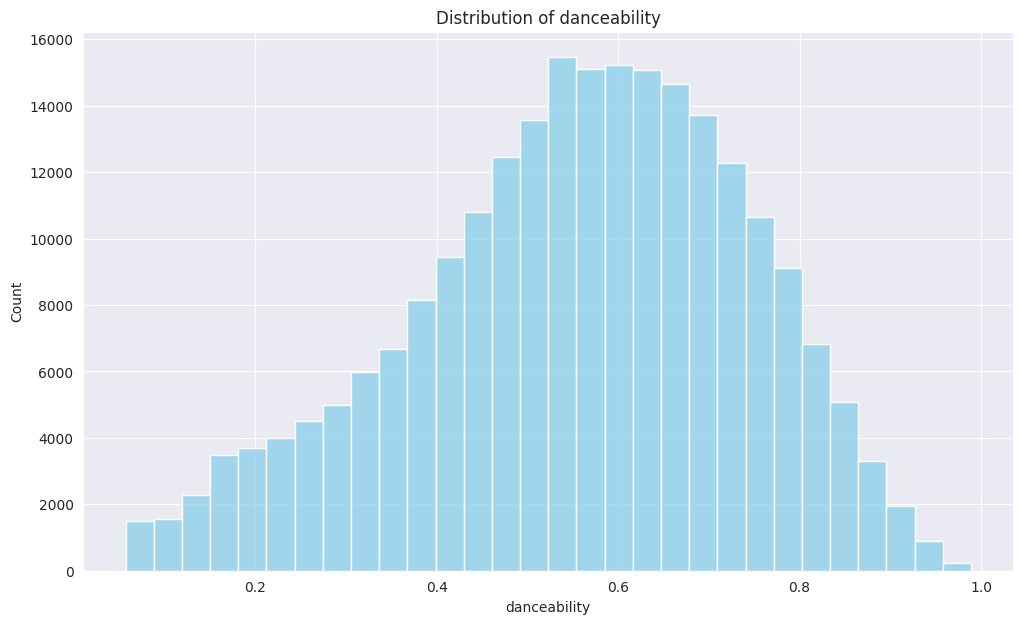

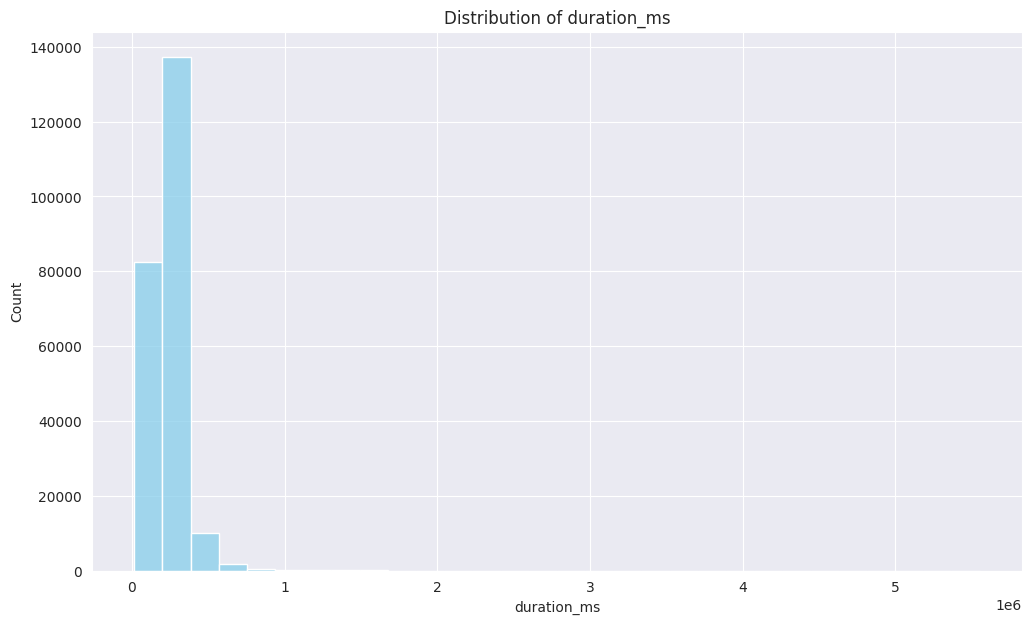

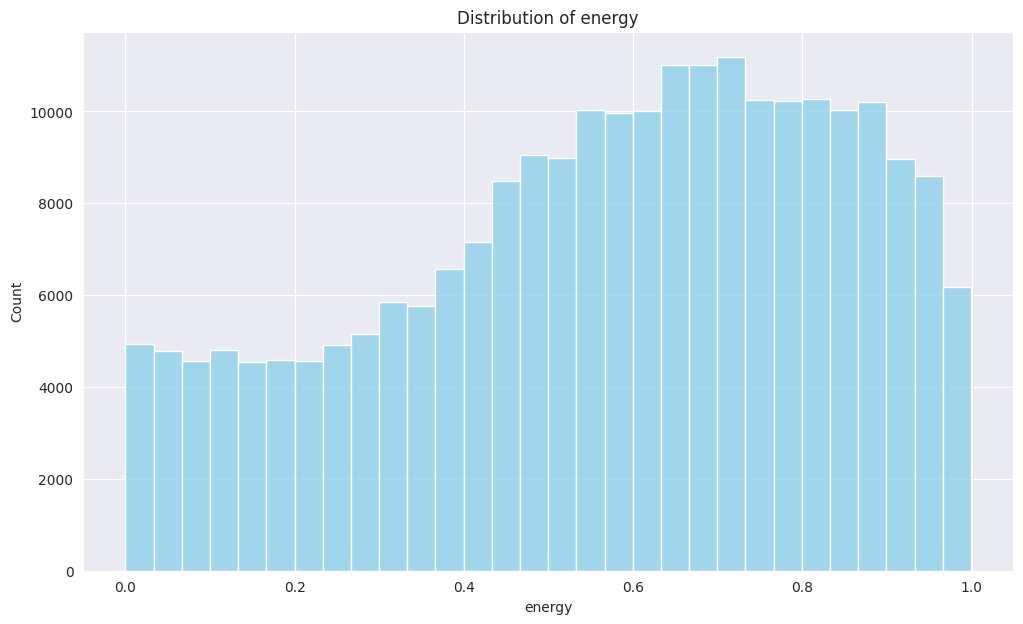

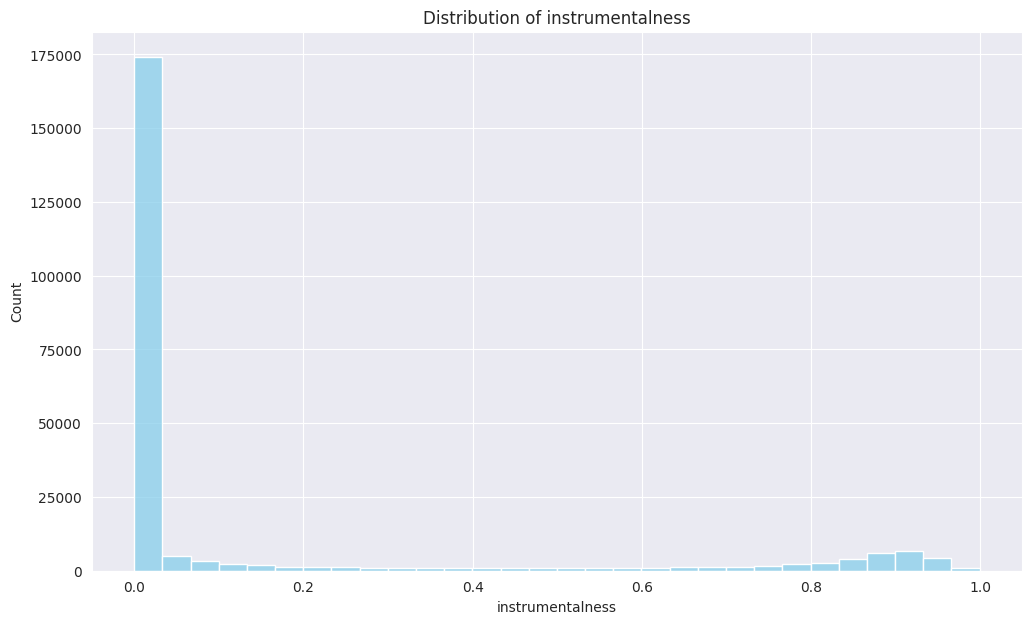

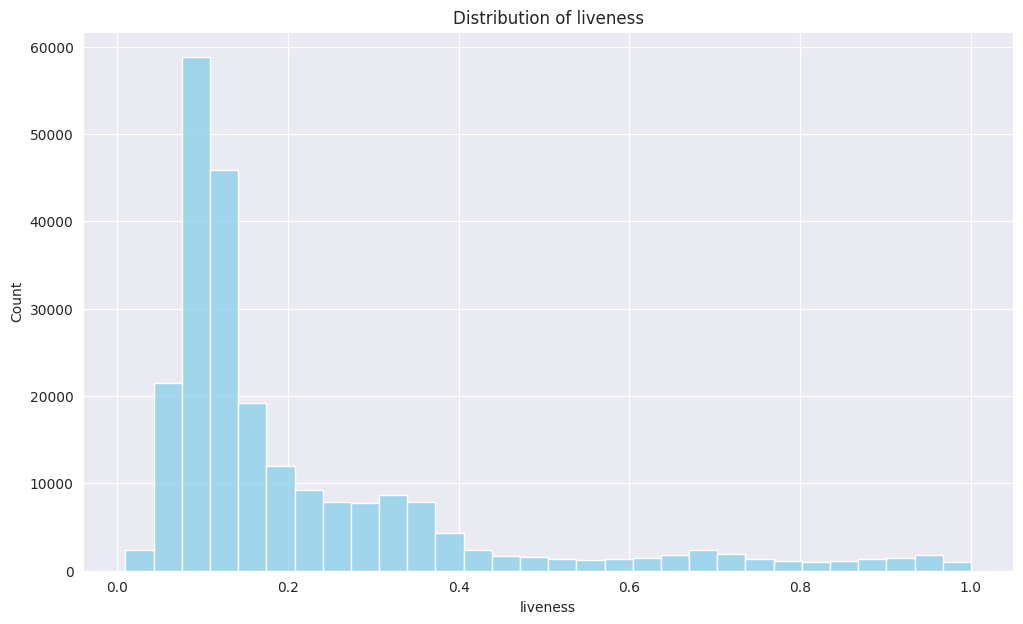

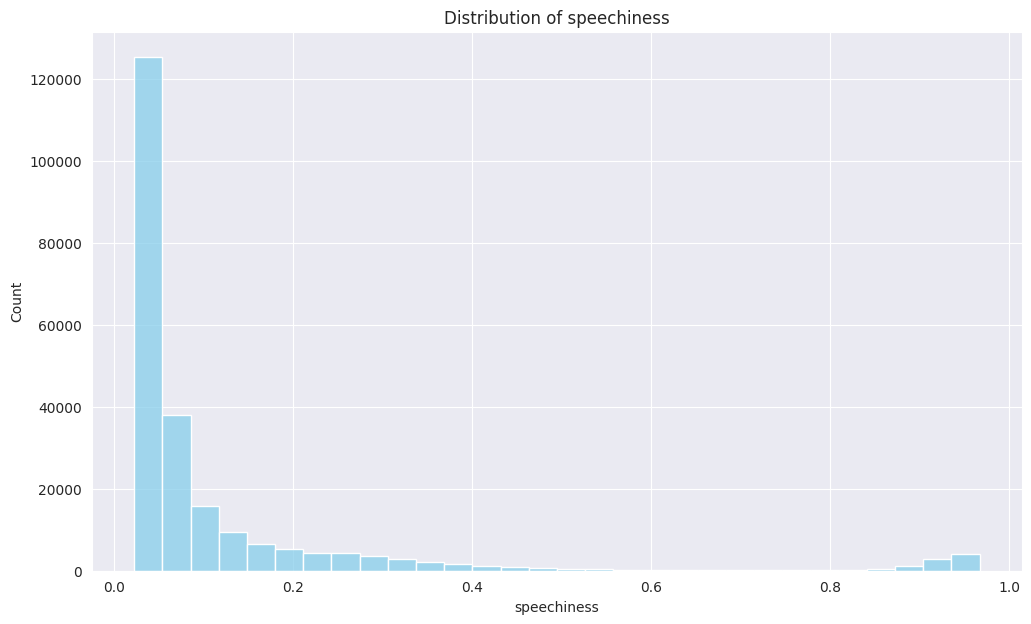

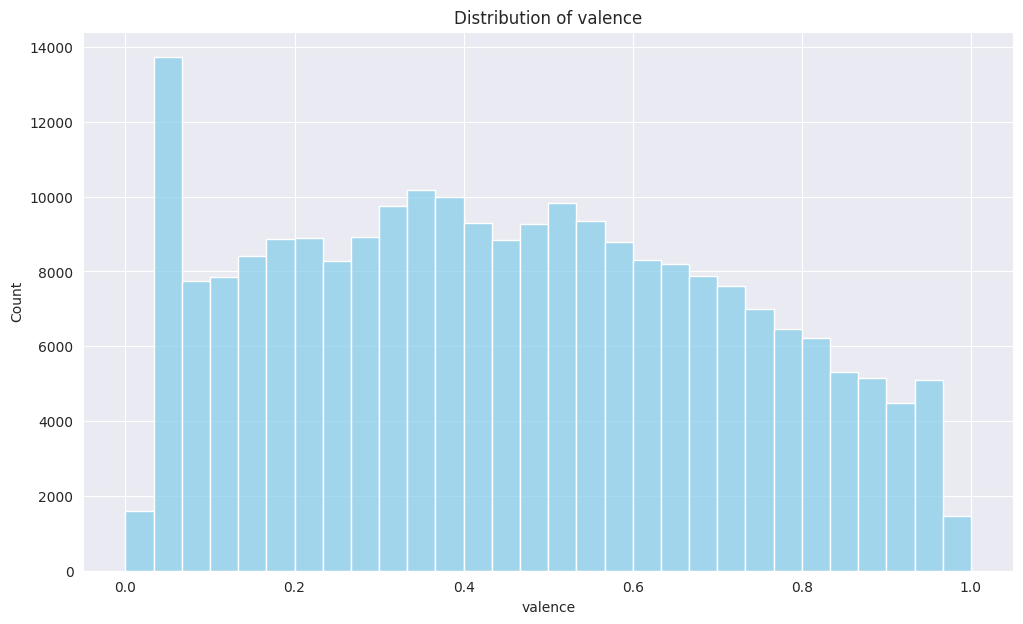

In [22]:
#Multiple Feature Plots
#Loops over features like tempo, loudness, etc., for all songs:

interested_features = ['tempo', 'loudness', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']

for feature_col in interested_features:
    plt.figure(figsize=(12,7))
    sns.histplot(df[feature_col], bins=30, color='skyblue')
    plt.title(f'Distribution of {feature_col}')
    plt.xlabel(feature_col)
    plt.ylabel('Count')
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


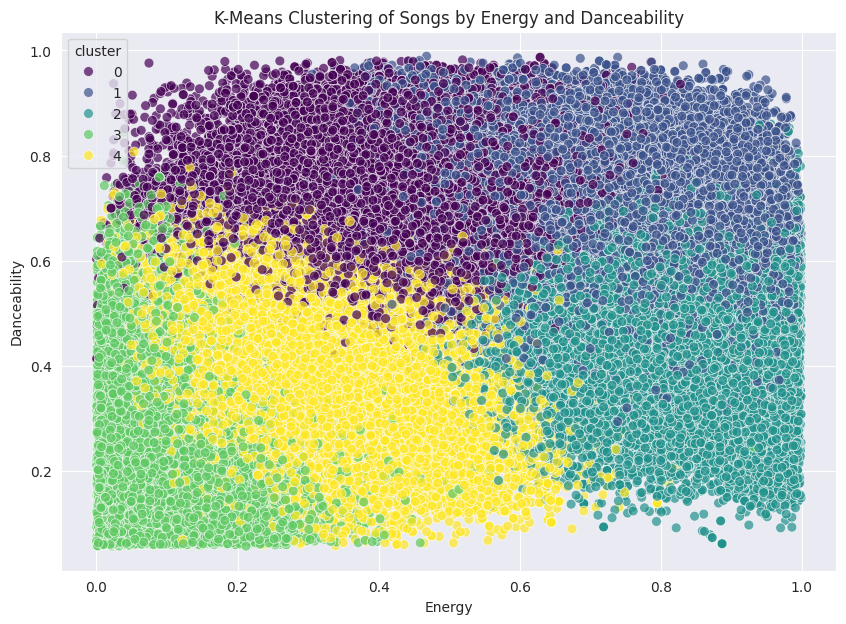

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

features = ['danceability', 'energy', 'loudness', 'valence']  # Select relevant cols
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='energy', y='danceability', hue='cluster', palette='viridis', s=50, alpha=0.7)
plt.title('K-Means Clustering of Songs by Energy and Danceability')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.grid(True)
plt.show()